In [383]:
#Se importan las librerias a utilizar

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
%matplotlib inline

In [384]:
import chardet

#Carga de datos

with open("CasasEnVenta_Madrid_NotDuplicates.csv", "rb") as f:
    result = chardet.detect(f.read())
    encoding_detected = result["encoding"]

data_sin_reps = pd.read_csv("CasasEnVenta_Madrid_NotDuplicates.csv", encoding=encoding_detected, sep=';', index_col='id')
print(data_sin_reps.head(5))

     precio  metros_cuadrados_totales  metros_cuadrados_utiles  numero_baNos  \
id                                                                             
1    650000                        78                       78             1   
2    525000                        70                       62             1   
3    795000                       127                      113             2   
4   3650000                       304                      290             5   
5   5100000                       310                      270             5   

    numero_habitaciones  planta  antigUedad vivienda_unifamiliar  \
id                                                                 
1                     2       2          66                   No   
2                     1       4          57                   No   
3                     5       4          54                   No   
4                     4       5          85                   No   
5                     4       6

## Análisis Outliers

In [385]:
# Vista de los tipos de datos y el tamaño del dataset (filas/registros y columnas/atributos).

data_sin_reps.info()

print("-------------------------------------")
print(f"Cantidad de filas: {data_sin_reps.shape[0]}")
print(f"Cantidad de columnas: {data_sin_reps.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
Index: 18077 entries, 1 to 19444
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   precio                    18077 non-null  int64 
 1   metros_cuadrados_totales  18077 non-null  int64 
 2   metros_cuadrados_utiles   18077 non-null  int64 
 3   numero_baNos              18077 non-null  int64 
 4   numero_habitaciones       18077 non-null  int64 
 5   planta                    18077 non-null  int64 
 6   antigUedad                18077 non-null  int64 
 7   vivienda_unifamiliar      18077 non-null  object
 8   tipo_vivienda             18077 non-null  object
 9   estado                    18077 non-null  object
 10  interior                  18077 non-null  object
 11  ascensor                  18077 non-null  object
 12  piscina                   18077 non-null  object
 13  trastero                  18077 non-null  object
 14  garaje                    1

In [386]:
print(data_sin_reps.columns)

Index(['precio', 'metros_cuadrados_totales', 'metros_cuadrados_utiles',
       'numero_baNos', 'numero_habitaciones', 'planta', 'antigUedad',
       'vivienda_unifamiliar', 'tipo_vivienda', 'estado', 'interior',
       'ascensor', 'piscina', 'trastero', 'garaje', 'terraza', 'balcon',
       'jardin', 'armarios', 'aire_acondicionado', 'calefaccion', 'geohash_6',
       'postal_code', 'municipio'],
      dtype='object')


In [387]:
#convertimos la variable "postal_code" a texto ya que es una variable geo y no numérica.

data_sin_reps['postal_code'] = data_sin_reps['postal_code'].astype(str)

var_numericas_tipos = data_sin_reps.select_dtypes(include=[np.number]).dtypes
print("VARIABLES NUMÉRICAS:\n")
print(var_numericas_tipos)

VARIABLES NUMÉRICAS:

precio                      int64
metros_cuadrados_totales    int64
metros_cuadrados_utiles     int64
numero_baNos                int64
numero_habitaciones         int64
planta                      int64
antigUedad                  int64
dtype: object


VALORES EN RANGOS DEL DOMINIO

Comenzamos con los criterios mínimos descritos en la PGOUM.
-Metros cuadrados útiles >=40m2.
-Que al menos tenga 1 baño.
-Que al menos tenga 1 habitacion.
-Que tengan luminosidad (esto es orientación y si la vivienda da al exterior, pero como orientación se descartó, solo podríamos decidir en cuanto a si la vivienda es interior o exterior, algo que ya se había analizado en pasos anteriores).
-Hay más criterios como que la vivienda tenga cocina y un dormitorio principal (con un mínimo de metros cuadrados); pero como esta información no se obtuvo como tal, no podemos aplicar más criterios de habitabilidad. Añadimos criterio de habitabilidad de que la planta debe ser mayor o igual que 0, que las viviendas situadas en plantas negativas se deben descartar por no cumplir con la normativa.

In [388]:
# Metros cuadrados útiles < 40m2.
print((data_sin_reps['metros_cuadrados_utiles'] < 40).sum())

608


Como hay 608 viviendas con un total de metros cuadrados útiles por debajo de 40m2; procedemos a eliminar dichos registros.

In [389]:
#Eliminamos valores
vars_review = ["metros_cuadrados_utiles", ]
print("Por el momento se tienen un total de",data_sin_reps.shape[0],"registros.\n")
for var in vars_review:
    data_sin_reps=data_sin_reps.drop(data_sin_reps[data_sin_reps[var]<40].index)
print("Tras eliminar los registros que se escapan del rango de valores, quedan",data_sin_reps.shape[0],"registros.\n")

Por el momento se tienen un total de 18077 registros.

Tras eliminar los registros que se escapan del rango de valores, quedan 17469 registros.



In [390]:
# Baños < 1.
print((data_sin_reps['numero_baNos'] < 1).sum())

31


Como hay 31 viviendas que no tienen baño, se eliminan.

In [391]:
#Eliminamos valores
vars_review = ["numero_baNos", ]
print("Por el momento se tienen un total de",data_sin_reps.shape[0],"registros.\n")
for var in vars_review:
    data_sin_reps=data_sin_reps.drop(data_sin_reps[data_sin_reps[var]<1].index)
print("Tras eliminar los registros que se escapan del rango de valores, quedan",data_sin_reps.shape[0],"registros.\n")

Por el momento se tienen un total de 17469 registros.

Tras eliminar los registros que se escapan del rango de valores, quedan 17438 registros.



In [392]:
# habitacion < 1.
print(((data_sin_reps['numero_habitaciones'] < 1) & (~data_sin_reps["tipo_vivienda"].isin(["Loft", "Estudio"]))).sum())

2


Como hay 2 viviendas que no tienen habitaciones que son de "tipo_vivienda" diferente a "Loft" y Estudio", se eliminan.

In [393]:
#Eliminamos valores
vars_review = ["numero_habitaciones", ]
print("Por el momento se tienen un total de",data_sin_reps.shape[0],"registros.\n")
for var in vars_review:
    data_sin_reps=data_sin_reps.drop(data_sin_reps[(data_sin_reps[var]<1) & (~data_sin_reps["tipo_vivienda"].isin(['Loft', 'Estudio']))].index)
print("Tras eliminar los registros que se escapan del rango de valores, quedan",data_sin_reps.shape[0],"registros.\n")

Por el momento se tienen un total de 17438 registros.

Tras eliminar los registros que se escapan del rango de valores, quedan 17436 registros.



Text(0, 0.5, 'DENSIDAD')

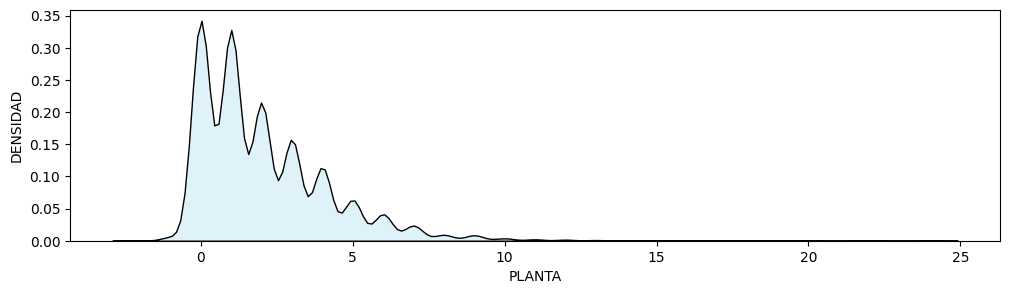

In [394]:
#PLANTA
plt.figure(figsize=(12, 3))
sns.kdeplot(data=data_sin_reps, x=data_sin_reps["planta"], fill=True, color='skyblue', edgecolor='black')
plt.xlabel("PLANTA")
plt.ylabel('DENSIDAD')

-Viendo por encima detectamos valores negativos en "Planta", primero vamos a tratar estos datos ya que afectan directamente a la normativa de habitabilidad en cuanto a luminosidad y ventilación.


PLANTA
max=24, min=-2

Text(0, 0.5, 'Frecuencia')

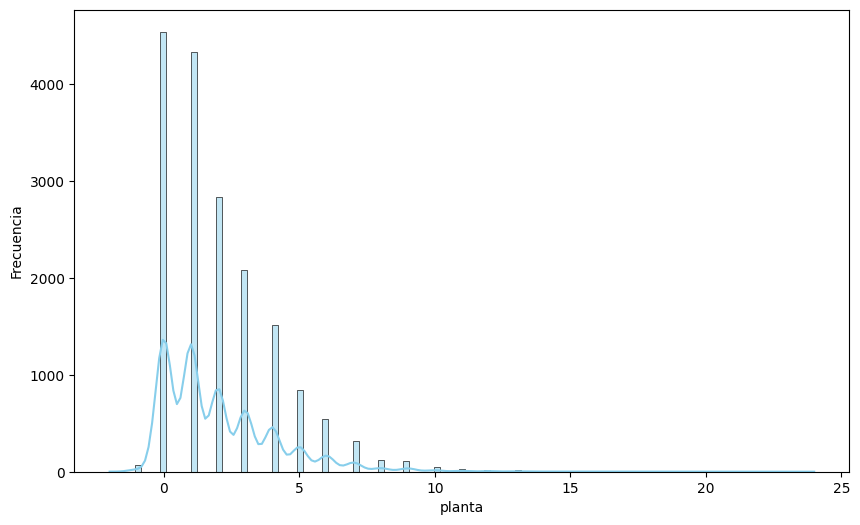

In [395]:
#Se había detectado que las viviendas podían estar en plantas -1 o -2, lo que es bastante inusual ya que se tratan de sótanos o incluso garajes que se están vendiendo como "casas".
#Esto es bastante "inhumano", por lo que descartaremos estas "viviendas".
#Hay un total de 83 viviendas con planta -1 o -2.
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps["planta"],  kde=True, color='skyblue', edgecolor='black')
plt.xlabel("planta")
plt.ylabel('Frecuencia')

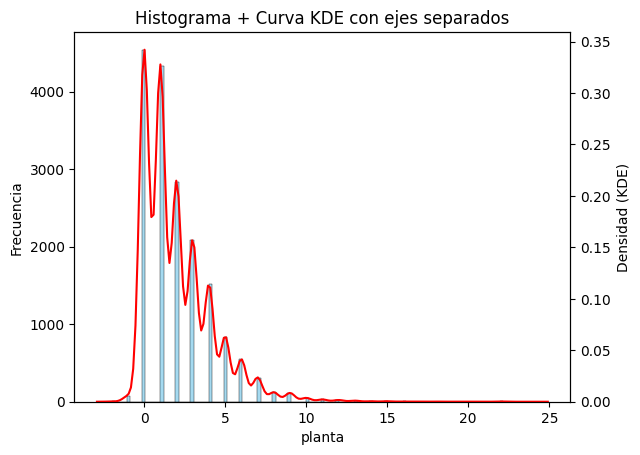

In [396]:
#OTRO TIPO DE GRÁFICO
fig, ax1 = plt.subplots()
sns.histplot(data_sin_reps["planta"], ax=ax1, color='skyblue')
ax1.set_ylabel('Frecuencia')

# Segundo eje para la KDE
ax2 = ax1.twinx()
sns.kdeplot(data=data_sin_reps, x=data_sin_reps["planta"], ax=ax2, color='red')
ax2.set_ylabel('Densidad (KDE)')

plt.title('Histograma + Curva KDE con ejes separados')
plt.show()

In [397]:
data_sin_reps[data_sin_reps["planta"]<0]

,precio,metros_cuadrados_totales,metros_cuadrados_utiles,numero_baNos,numero_habitaciones,planta,antigUedad,vivienda_unifamiliar,tipo_vivienda,estado,...,garaje,terraza,balcon,jardin,armarios,aire_acondicionado,calefaccion,geohash_6,postal_code,municipio
id,,,,,,,,,,,,,,,,,,,,,
9,475000,58,58,1,1,-1,66,No,Piso,Segunda mano/buen estado,...,No,No,No,No,No,No,Individual,ezjq5b,28010,Madrid
120,275000,44,44,1,1,-1,76,No,Piso,Segunda mano/buen estado,...,No,No,No,No,No,Si,Individual,ezjq58,28015,Madrid
240,450000,61,61,2,2,-1,99,No,Piso,Segunda mano/buen estado,...,No,No,No,No,Si,Si,Individual,ezjq5b,28010,Madrid
241,359000,67,66,1,1,-1,85,No,Piso,Segunda mano/buen estado,...,No,No,No,No,No,No,Individual,ezjq5c,28010,Madrid
306,780000,163,148,2,5,-1,75,No,Piso,Segunda mano/para reformar,...,No,No,No,No,No,Si,Sin Calefaccion,ezjq5b,28010,Madrid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11021,245000,58,58,1,2,-1,85,No,Piso,Segunda mano/buen estado,...,No,No,No,No,No,No,Individual,ezjq5s,28039,Madrid
11465,155000,67,67,1,2,-1,65,No,Piso,Segunda mano/para reformar,...,No,No,No,No,No,No,Sin Calefaccion,ezjmez,28026,Madrid
11490,158000,59,59,2,2,-1,52,No,Piso,Segunda mano/buen estado,...,No,Si,No,No,No,No,Sin Calefaccion,ezjmex,28026,Madrid


In [398]:
#Eliminamos valores negativos (pues son valores no aptos para el dominio del estudio)
vars_review = ["planta", ]
print("Por el momento se tienen un total de",data_sin_reps.shape[0],"registros.\n")
for var in vars_review:
    data_sin_reps=data_sin_reps.drop(data_sin_reps[data_sin_reps[var]<0].index)
print("Tras eliminar los registros con valores negativos, quedan",data_sin_reps.shape[0],"registros.\n")

Por el momento se tienen un total de 17436 registros.

Tras eliminar los registros con valores negativos, quedan 17362 registros.



ANTES DE COMENZAR CON EL ANÁLISIS DE VARIABLES DEFINIMOS UNA SENTENCIA LÓGICA Y ES QUE LOS METROS CUADRAOS UTILES NO PUEDEN SUPERAR A LOS METROS CUADRADOS TOTALES DE LA CASA.
-Se comprueba también que el el número de "metros_cuadrados_utiles" no es mayor que el número de "metros_cuadrados_totales".
Estos casos serían un error y habría que eliminarlos, pero no hay ningún registro con esta casuística.

In [399]:
# Se comprueba que hay registros erróneos de este tipo.
print((data_sin_reps['metros_cuadrados_utiles'] > data_sin_reps['metros_cuadrados_totales']).sum())

0


FIN VALORES EN RANGOS DEL DOMINIO

**Detección de "Outliers".**. ---EXPLICAR BIEN ESTO y cambiar a IQR


¿Qué es un "outlier"? - introducción de término.

Además de aplicar los criterios mínimos de "habitabilidad"; de forma estándar, es muy frecuente clasificar que un dato es “outlier” cuando su valor es superior a la media más el doble (o X) de la desviación estándar (std) de dicha característica (o inferior del valor de la media menos el doble de la desviación estándar), pero en este objeto de estudio, las avriables presentan asimetría positiva a la derecha, y al no seguier u na distribución normal, será mejor opción utilizar el criterio de rangos intércuartílicos IRC (puntuación Z). No obstante, el analista deberá decidir esta clasificación de “outliers” entendiendo completamente los datos que obviamente estarán relacionados con el sector al que pertenecen. Además, tener una desviación típica mayor que la media son indicaciones de que los datos son demasiado distintos y esto hará que el modelo no entrene/ajuste bién.

La función para detectar "outliers" sería fijando el límite inferior y el límite superior de los valores "aceptables":

Lim_inf = Q1 - 1,5*RIC

Lim_sup = Q3 + 1,5*RIC

El analísta tendrá que expecificar los rangos (limite inferior y límite superior) de valores posibles para cada característica y decidir si un valor fuera de esos rangos se debe clasificar como "outlier".

Según hemos analizado cada una de las características, únicamente podrían presentar "outliers" las variables numéricas pues las variables categóricas ya han sido estandarizadas correctamente aunque si que tendremos que decidir que hacer con categorías/clases poco balanceadas y asu vez .

Como en el caso de los "Missing Values", los valores "outliers" podrían ajustarse (con extrapolación utilizando otras variables, interpolación, etc)) o eliminarse del dataset (si suponen un porcentaje muy pequeño del total de los registros y pemite continuar con un volumen apto/suficiente para aplicar modelos de regresión).

Ya se ha hecho un gran esfuerzo en la estandarización de datos, por lo que ahora no vamos a perder tanto tiempo.
Ahora tendremos que tomar decisiones para datos que parezcan "extraños" que pueden deberse por error de la persona que sube el anuncio, por un timo o simplemente por que la persona que quiere vender la propiedad se quiere aprovechar.

EMPEZAMOS A ANALIZAR CADA VARIABLE DE UNA EN UNA VARIABLE

# Vamos a ver el análisis completo de cada caraterística.

In [400]:
var_numericas = data_sin_reps.select_dtypes(include=[np.number])

for var in  var_numericas:

    print("Característica:", var, "\n\n",data_sin_reps[var].describe().T,"\n\n\n") 

Característica: precio 

 count    1.736200e+04
mean     9.333566e+05
std      1.213432e+06
min      2.490000e+04
25%      2.749000e+05
50%      5.005500e+05
75%      1.150000e+06
max      2.300000e+07
Name: precio, dtype: float64 



Característica: metros_cuadrados_totales 

 count     17362.000000
mean        265.903640
std        5875.052685
min          40.000000
25%          84.000000
50%         130.000000
75%         232.000000
max      600000.000000
Name: metros_cuadrados_totales, dtype: float64 



Característica: metros_cuadrados_utiles 

 count     17362.000000
mean        213.144223
std        3602.262308
min          40.000000
25%          78.000000
50%         120.000000
75%         220.000000
max      474000.000000
Name: metros_cuadrados_utiles, dtype: float64 



Característica: numero_baNos 

 count    17362.000000
mean         2.464002
std          1.542292
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         20.000000
N

In [401]:
# Veamos el número de candidatos a "outliers" de cada caractrística.
atip = 0
for var in var_numericas:
    Q1 = data_sin_reps[var].quantile(0.25)
    Q3 = data_sin_reps[var].quantile(0.75)
    RIC = Q3 - Q1
    mean = data_sin_reps[var].mean()
    lim_inf, lim_sup = Q1 - 1.5*RIC, Q3 + 1.5*RIC
    datos_atipicos = pd.concat([data_sin_reps[data_sin_reps[var]<lim_inf], data_sin_reps[data_sin_reps[var]>lim_sup]]).sort_index()
    atipicos = datos_atipicos.shape[0]
    atip=atip+atipicos
    print("La característica", var, "tiene un total de", atipicos, "valores atipicos")
print("se tienen un total de",atip, "valores atipicos que muchos de ellos serán de los mismos registros")

La característica precio tiene un total de 1325 valores atipicos
La característica metros_cuadrados_totales tiene un total de 1268 valores atipicos
La característica metros_cuadrados_utiles tiene un total de 1297 valores atipicos
La característica numero_baNos tiene un total de 366 valores atipicos
La característica numero_habitaciones tiene un total de 319 valores atipicos
La característica planta tiene un total de 373 valores atipicos
La característica antigUedad tiene un total de 557 valores atipicos
se tienen un total de 5505 valores atipicos que muchos de ellos serán de los mismos registros


Todas las variables numéricas tienen valores atípicos, por lo que vamos a revisarlas de una en una y vamos a tomar decisiones.
Como el precio es la variable objetivo, comenzaremos con el resto de variables primero.

In [402]:
# Vamos a estudiar los valores atípicos de la variable "planta"

var = "planta"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

# El máximo es 24 plantas, lo que llama la atención ya que Madrid es una ciudad alta, pero no tanto. Los edificios más altos, suelen ser oficinas.
# El número mínimo es 0, una planta baja ya que se descartaron los valores negativos.
# La desviación estándar es ligeramente superior a la media que está en 2, lo que indica que Madrid tampoco es una ciudad "muy alta".

Media: 2.0 

Desviación Estándar: 2.1419702457044885 

Máximo: 24 

Mínimo: 0 



Text(0, 0.5, 'Frecuencia')

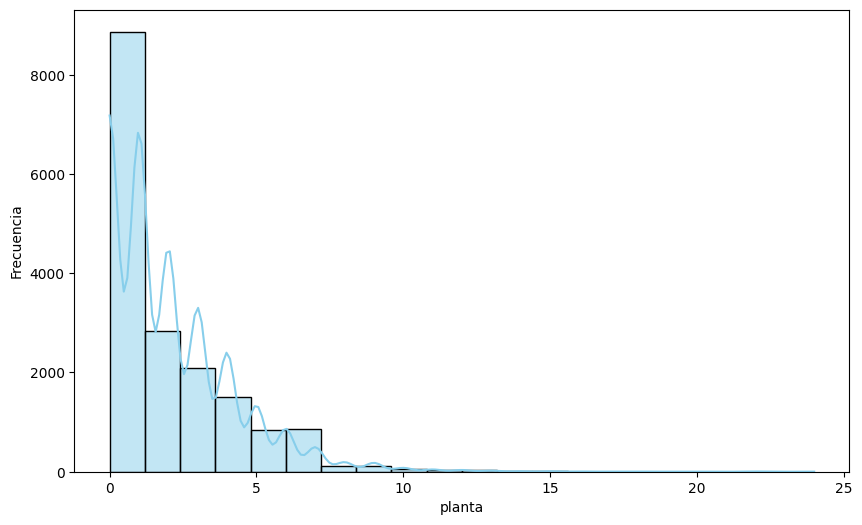

In [403]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  bins=20, kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

-Claramente observamos que viviendas a partir de una planta 10 son muy pocas, pero son casos probables (no es un "outlier"). Evidentmente la "planta" si es una cartacterística que afecta en la decisión del comprador (cuestiones de lumninosidad, ventilación, ruido, privacidad, vistas, menos presencia de bichos y otros animales y dificultad extra para delincuentes) y por tanto influye en el precio. Aunque seguramente, el número de planta tenga su punto de saturación y por más altura que se tenga, la vivienda ya no es más cara (pues empiezan a entrar cuestiones de que se tarda más en subir en ascensor o se tiene la casuística de todo lo que hay que subir andando si alguna vez el ascensor no funciona o simplemente el inconveniente de que en el ascensor no te quepan por ejemplo los muebles y se tebgan que subir por las escaleras...); lo que hace que tener más altura deja de ser atractivo y comienza a ser incoveniente (a más altura el precio ya no sube más, casi que comienza a bajar). ESTO SE VERÁ MEJOR CUANDO SEPAMOS LA MEDIA DE ALTURA DE LOS PISOS EN MADRID, FORTALECE MUCHO ESTOS ARGUMENTOS.

-Veamos la distribución del número de plantas según el tipo de vivienda.

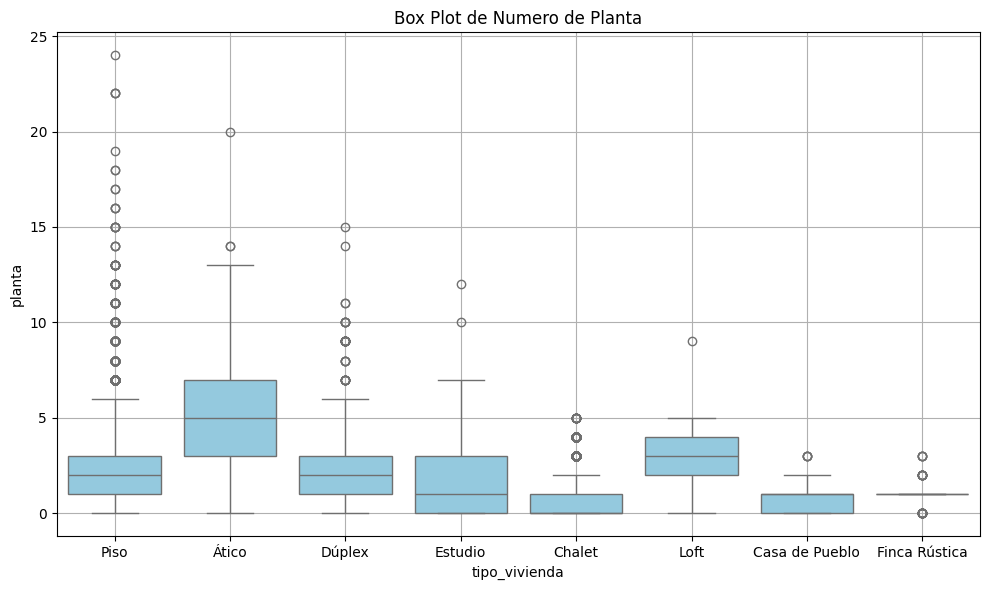

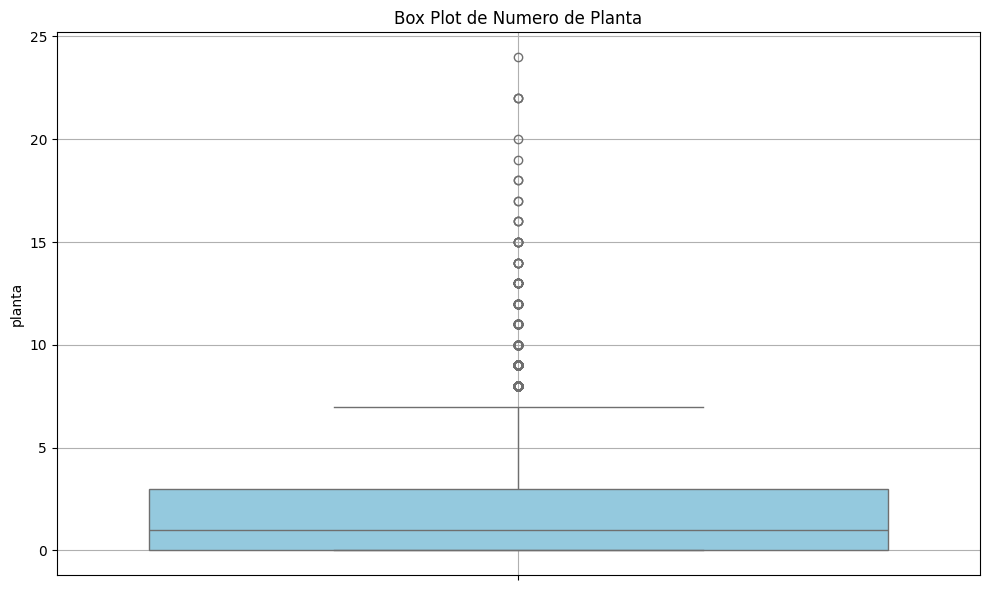

In [404]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Planta')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Planta')
plt.grid(True)
plt.tight_layout()
plt.show()


Aunque en Madrid existen restricciones de altura de los edificios por zona, sobre todo esto aplicaría a nuevas construcciones.
Tampoco son casos super atípicos, no es una planta que claramente veamos como imposible o muy muy extraño...simplemente menos frecuentes ya que Madrid no es una ciudad muy "alta".
No encontramos nada extraño en la distribución de "planta" pero si que vemos que las viviendas que estén en plantas superiores a 11, serán muy excasas y por tanto podríamos optar por sacar dichos registros de nuetro dataset.
Finalmente, con el objetivo de mantener un mínimo de estandarización (cumplir que la std es menor que la media), decidimos eliminar las viviendas que se encuentren en una planta 11 o superior.

In [405]:
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
datos_atipicos = data_sin_reps[data_sin_reps[var]>10].sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar las viviendas que estén en una planta 11 o superior, quedan ",data_sin_reps.shape[0]," registros.\n")

std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()

print("Ahora si logramos cumplir que la std: ", std," es ligeramente menor que la media:", mean)

Por el momento se tienen un total de  17362  registros.

Tras eliminar las viviendas que estén en una planta 11 o superior, quedan  17272  registros.

Ahora si logramos cumplir que la std:  1.9802745409749112  es ligeramente menor que la media: 1.9924154701250578


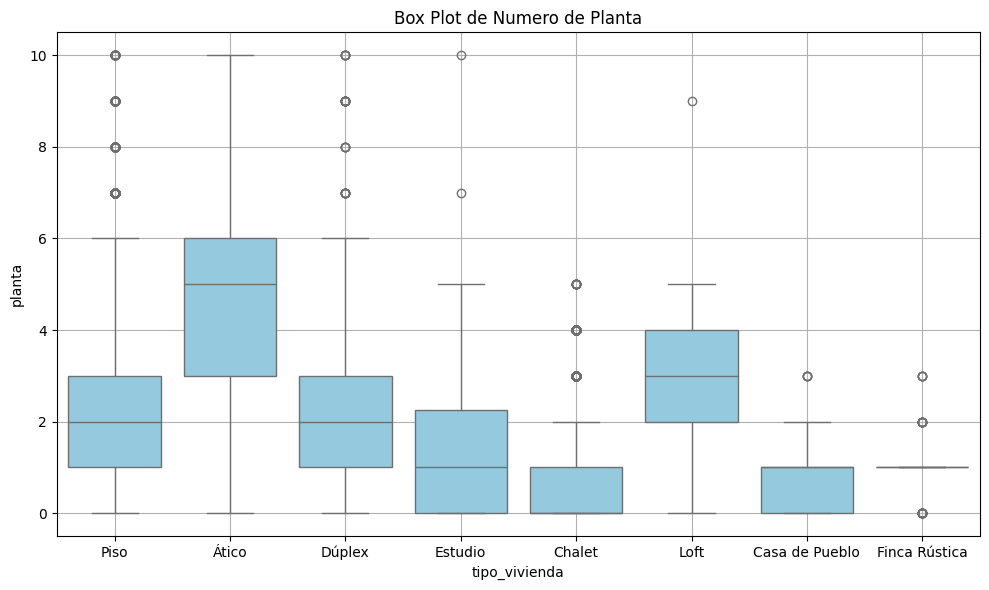

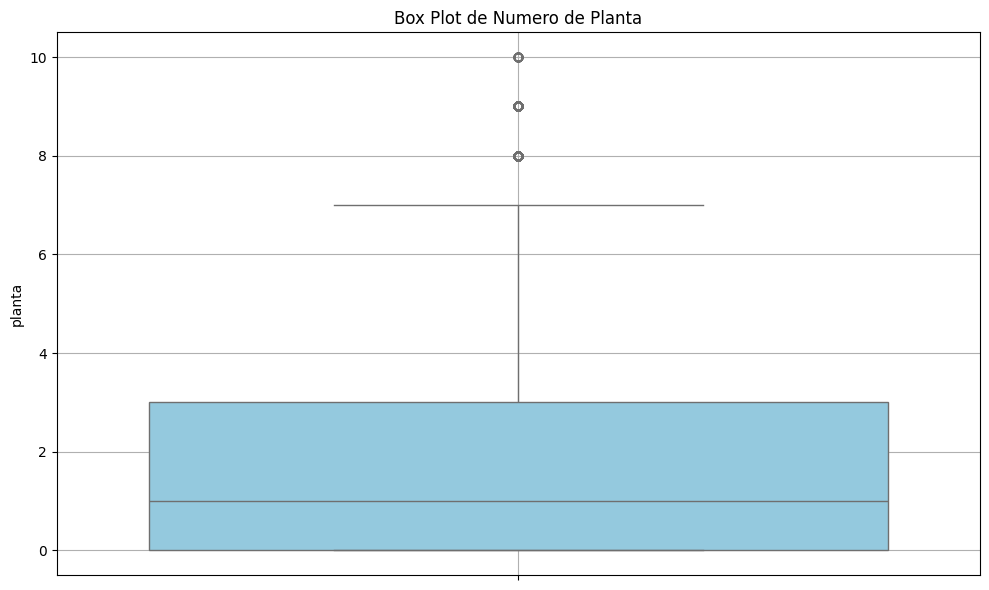

In [406]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Planta')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Planta')
plt.grid(True)
plt.tight_layout()
plt.show()


In [407]:
# Vamos a estudiar los valores atípicos de la variable "metros_cuadrados_utiles"

var = "metros_cuadrados_utiles"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")


# La desviación estándar es muy grande porque se tienen datos de chalets con características muy diferentes.
# El máximo es 474.000 m2 lo que es imposible; quizás pusieron 3 ceros de más, pero aquí ha bailado algo.
# El mínimo ya se habia asegurado con los rangos de valores y la normativa de que tiene que ser de al menos 40m2.


Media: 213.0 

Desviación Estándar: 3611.6267578131256 

Máximo: 474000 

Mínimo: 40 



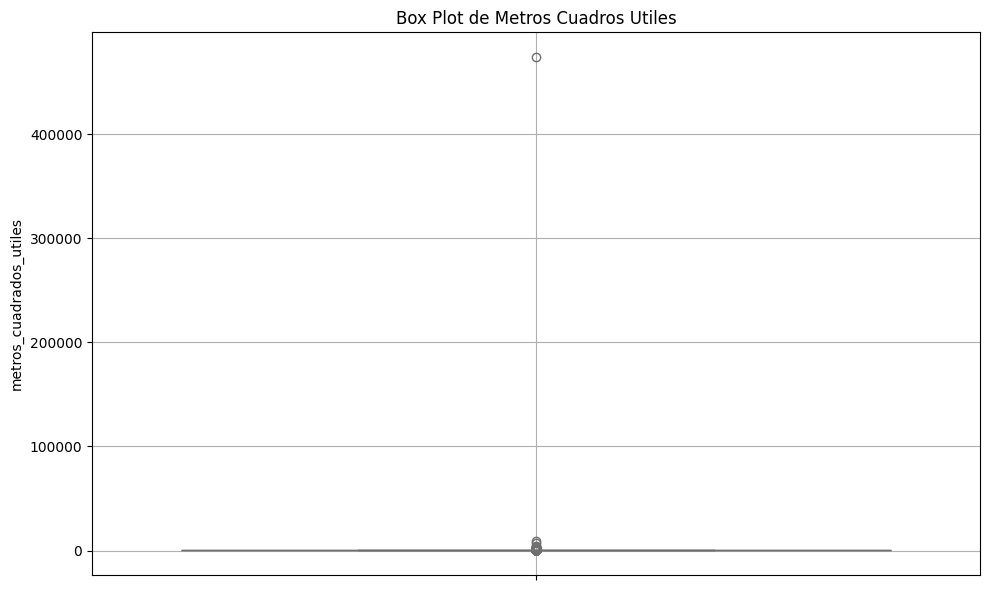

In [408]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadros Utiles')
plt.grid(True)
plt.tight_layout()
plt.show()

In [409]:
#vamos a quitar el dato erróneo
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
datos_atipicos = data_sin_reps[data_sin_reps[var]>400000].sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")

Por el momento se tienen un total de  17272  registros.

Tras eliminar los registros con valores atípicos, quedan  17271  registros.



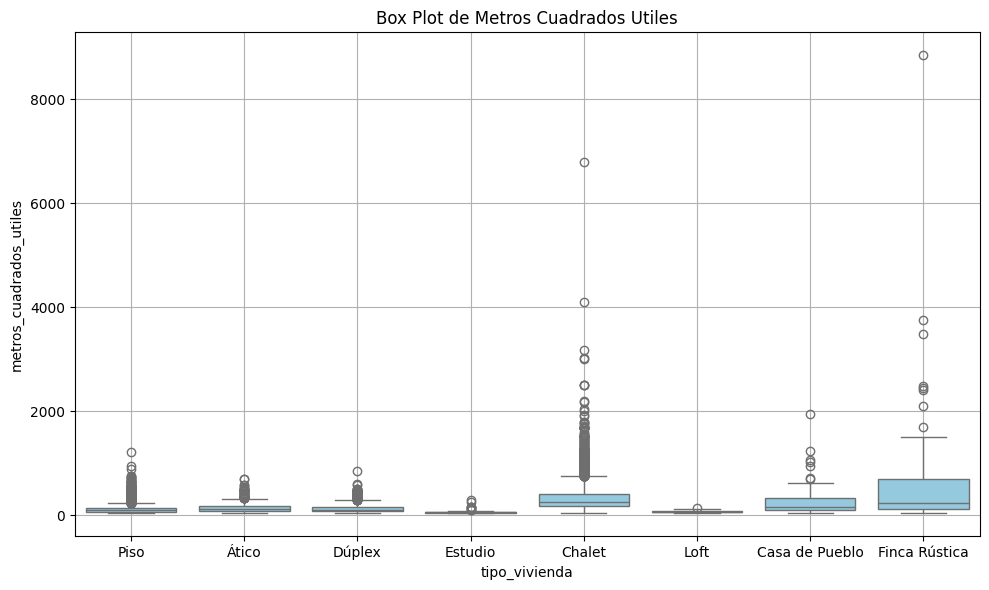

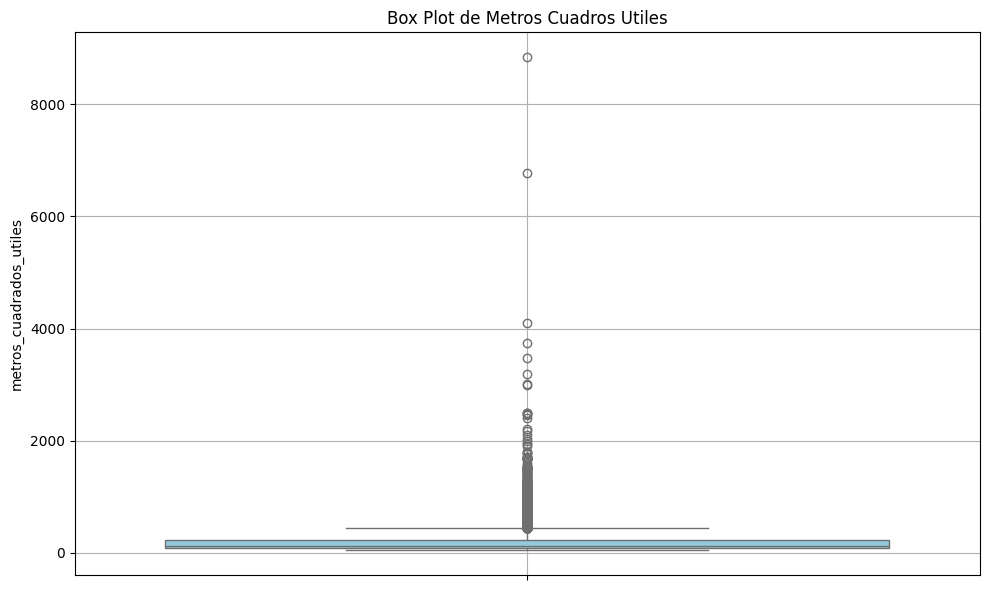

In [410]:
#Pintamos el diagrama de bigotes de la variable "metros_cuadrados_utiles" para cada tipo de vivienda para sacar más conclusiones
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadrados Utiles')
plt.grid(True)
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadros Utiles')
plt.grid(True)
plt.tight_layout()
plt.show()

In [411]:
# Según información de Madrid, la vivienda más grande es de 2.700 m2 útiles, que es gigante. ¿De donde sale esto? ¿Que web puedo utilizar?
# https://www.remaxwelcome.es/datos-sobre-la-casa-ideal-de-los-espanoles-y-donde-invertir-en-madrid
# Aún asi, este tipo de viviendas suelen ser mansiones lujosas que se escapan mucho de la vivienda habitual de la que queremos centrar el estudio.
# Por decisión propia, vamos a eliminar las viviendas con más de 1.0000 metros cuadrados utiles. Pues la media de metros utiles de un chalet en Madrid provincia es de unos 100-200 m2. ¿De donde sale esto? ¿Que web puedo utilizar?
# Aun asi, 1.0000 m2 cuadrados últiles es claramente una vivienda que se escapa de nuestro estudio, por lo que tendremos que revisar si los datos ya encajan más.
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
datos_atipicos = data_sin_reps[data_sin_reps[var]>1000].sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")

Por el momento se tienen un total de  17271  registros.

Tras eliminar los registros con valores atípicos, quedan  17117  registros.



In [412]:
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")


# La desviación estándar ya es bastante más ajustada.
# El máximo es 1.000 m2 que puede seguir perjudicando a la muestra.
# En cambio, el mínimo es 40 m2, que si que puede ser una vivienda real estipulado por la Ley.

Media: 174.0 

Desviación Estándar: 149.61534379915665 

Máximo: 1000 

Mínimo: 40 



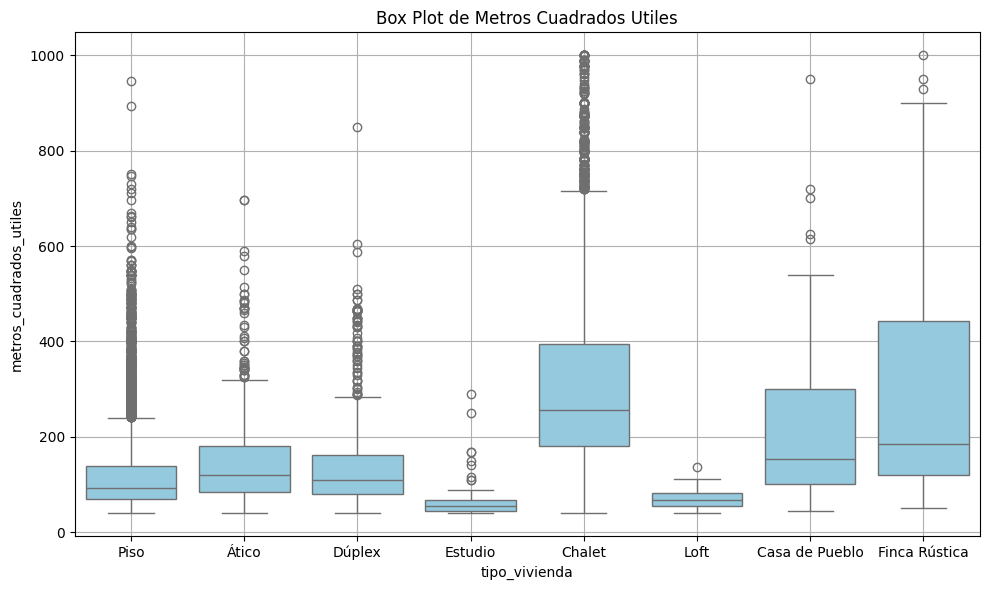

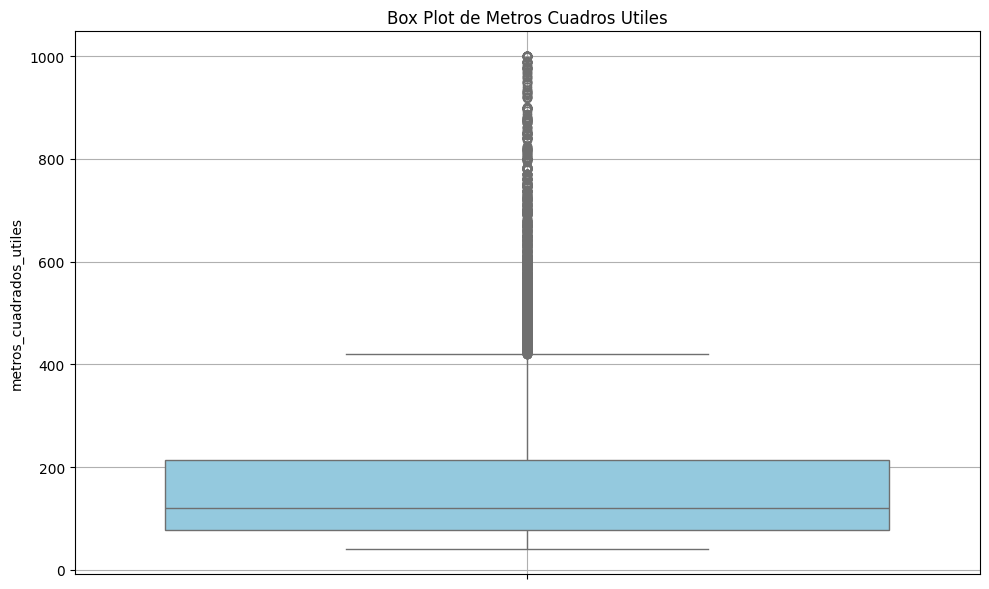

In [413]:
#Pintamos el diagrama de bigotes de la variable "metros_cuadrados_utiles" para cada tipo de vivienda para sacar más conclusiones
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadrados Utiles')
plt.grid(True)
plt.tight_layout()
plt.show()

# Este grafico sigue demostrando que hay muchos valores que se escapan de lo habitual; pero podrían ser posibles, ya que hay viviendas de diversos tamaños y muchas
# de ellas pueden ser muy grandes. Hay que tomar decisiones e intentar ajustar mejor los datos.


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadros Utiles')
plt.grid(True)
plt.tight_layout()
plt.show()

Aquí ya se ven claras conclusiones.

-Los chalets, casa rústica e incluso las ·casas de Pueblo· son los que tienen las viviendas más grandes y estudio y lofts son los que tienen las viviendas mas pequeñas.

-Llama la atención que haya pisos tan grandes de más de 200m2; pero es cierto que lss casas antiguas tienen bastantes metros cuadrados y esto habrá que revisarlo con lupa.

In [414]:
# APLICACION RANGOS INTERCUARTILICOS

# vamos a quitar los datos atípicos de "metros_cuadrados_utiles" ya que aunque estos valores podrían ser reales, intentaremos quedarnos con una muestra más "cercana" 
# y que no quede desvirtuado el modelo. Para ser cautelosos
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")

# Iteramos por cada tipo de vivienda
for tipo in data_sin_reps['tipo_vivienda'].unique():
    grupo = data_sin_reps[data_sin_reps['tipo_vivienda'] == tipo]
    
    Q1 = grupo[var].quantile(0.25)
    Q3 = grupo[var].quantile(0.75)
    RIC = Q3 - Q1
    
    # Límites RIC (1.5*RIC es lo habitual, puedes ajustarlo)
    lim_sup = Q3 + 1.5*RIC
    lim_inf = Q1 - 1.5*RIC
    
    # Detectar outliers
    #outliers = grupo[(grupo[var] > lim_sup) | (grupo[var] < lim_inf)]
    outliers = grupo[(grupo[var] > lim_sup)]
    
    # Eliminar outliers del dataset
    #data_sin_reps = data_sin_reps.drop(outliers.index)
    
print("Tras eliminar los registros con valores atípico por RIC, quedan ", data_sin_reps.shape[0]," registros.\n")

Por el momento se tienen un total de  17117  registros.

Tras eliminar los registros con valores atípico por RIC, quedan  17117  registros.



Text(0, 0.5, 'Frecuencia')

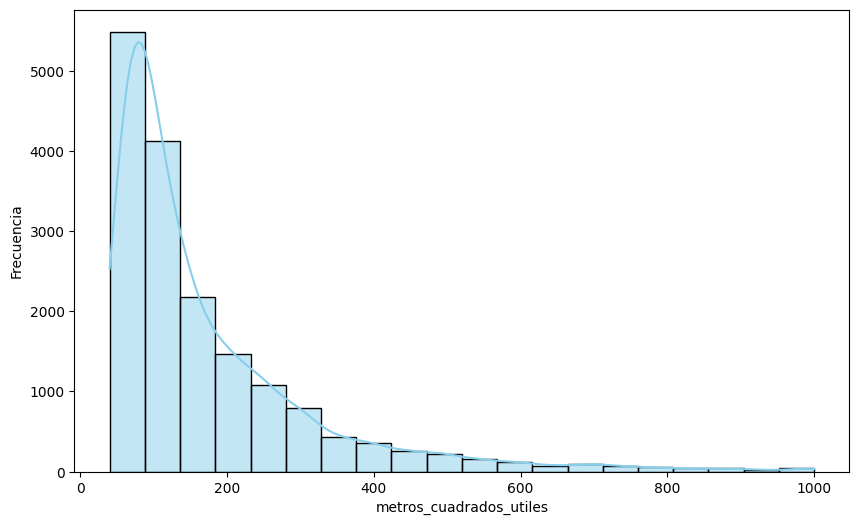

In [415]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  bins=20, kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

In [416]:
# Vamos a estudiar los valores atípicos de la variable "metros_cuadrados_totales"

var = "metros_cuadrados_totales"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

# La desviación estandar sigue siendo muy grande, por lo que hay que eliminar "outliers". 
# El máximo (600.000 m2) es gigante no tiene sentido para nuestro estudio.

Media: 221.0 

Desviación Estándar: 4595.535468285352 

Máximo: 600000 

Mínimo: 40 



Text(0, 0.5, 'Frecuencia')

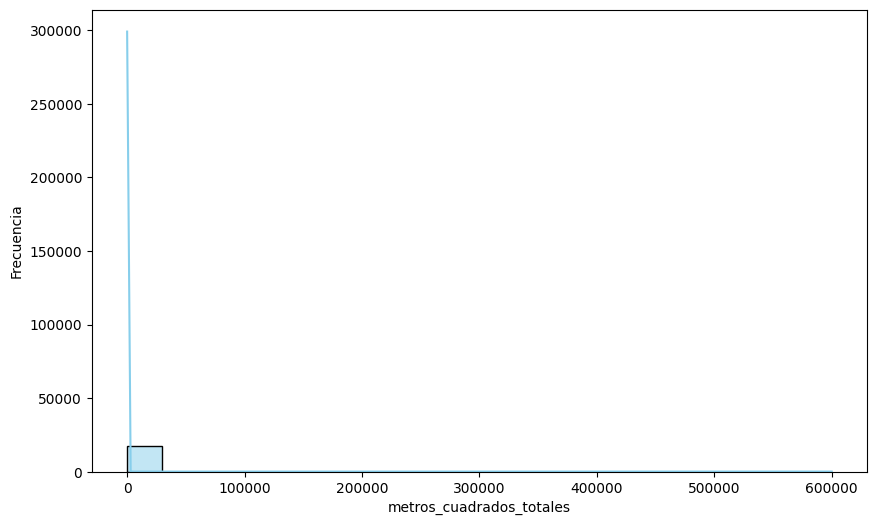

In [417]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  bins=20, kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

In [418]:
#vamos a quitar los datos atípicos de "metros_cuadrados_totales" ya que aunque estos valores podrían ser reales, intentaremos quedarnos con una muestra más "cercana" 
# y que no quede desvirtuado el modelo.
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
datos_atipicos = data_sin_reps[data_sin_reps[var]>mean+2*std].sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")

Por el momento se tienen un total de  17117  registros.

Tras eliminar los registros con valores atípicos, quedan  17115  registros.



Media: 184.0 

Desviación Estándar: 159.13216740978595 

Máximo: 2800 

Mínimo: 40 



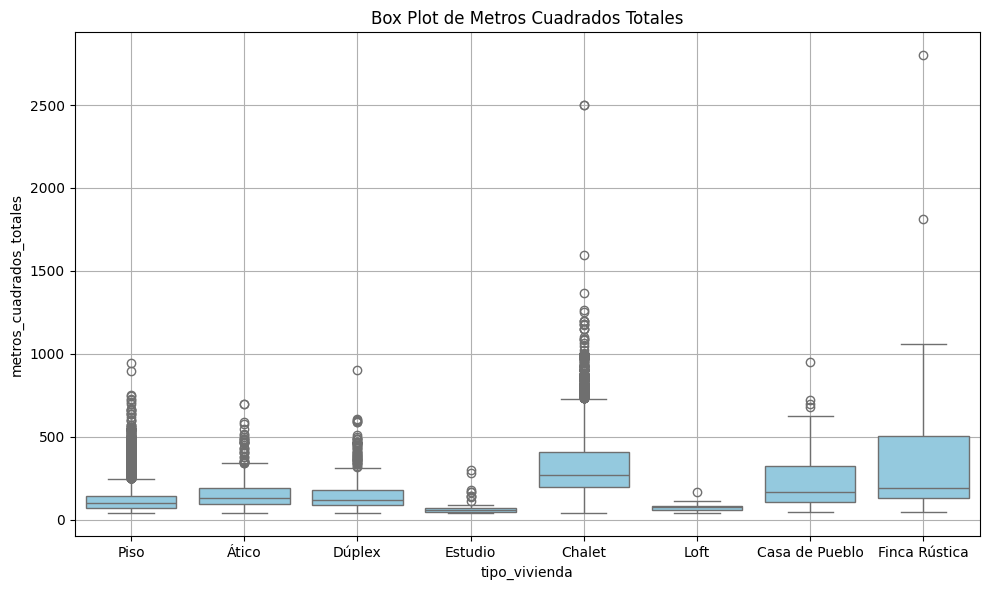

In [419]:
# Vamos a estudiar los valores atípicos de la variable "metros_cuadrados_totales"

std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

#Pintamos el diagrama de bigotes de3 la variable "metros_cuadrados_totales" para cada tipo de vivienda para sacar más conclusiones
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadrados Totales')
plt.grid(True)
plt.tight_layout()
plt.show()

# La desviación estándar ya es más pequeña.
# El máximo es 2.500 m2, que podría ser real...Pero aún así lo vamos a eliminar para quedar con una muestra más similar en cuanto a m2 totales.

#NNO APLICO ESTE FILTRAJE, NO ES NECESARIO
# sigue habiendo valores atípicos de "metros_cuadrados_totales" por lo que vamos a repetir la criba, pero siendo más cautelosos en cuanto al límite superior
# y que no quede desvirtuado el modelo.
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
datos_atipicos = data_sin_reps[data_sin_reps[var]>2500].sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")

# Vamos a estudiar los valores atípicos de la variable "metros_cuadrados_totales"

std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

#Pintamos el diagrama de bigotes de3 la variable "metros_cuadrados_utiles" para cada tipo de vivienda para sacar más conclusiones
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadrados Totales')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Metros Cuadrados Totales')
plt.grid(True)
plt.tight_layout()
plt.show()

# La desviación estándar ya es muy aceptable.
# El máximo son  1812 m2 y la desviación ya ha bajado de 100, por lo que podemos dar esta variable como apta aunque visualmente seguimos observando que hay valores "atípicos".


Text(0, 0.5, 'Frecuencia')

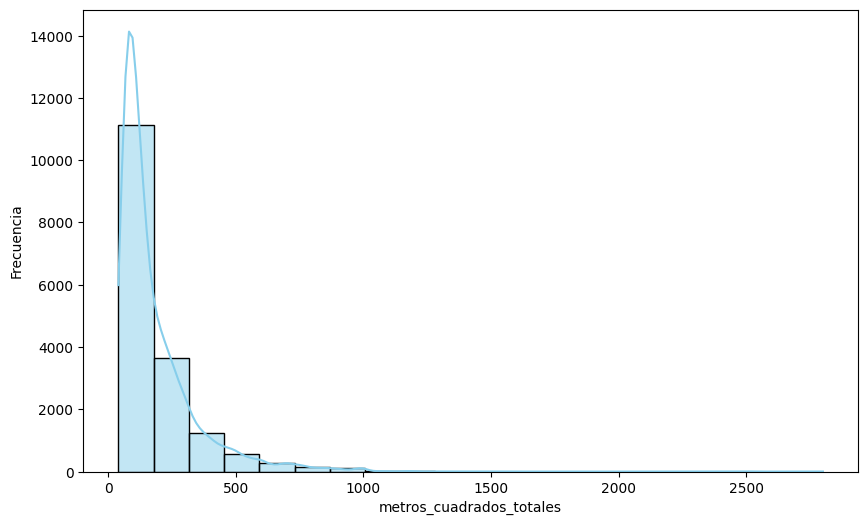

In [420]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  bins=20, kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

In [421]:
# Vamos a estudiar los valores atípicos de la variable "numero_baNos"

var = "numero_baNos"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,2),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

# El máximo es bastante atípico, ya que no es común que una vivienda habitual se tengan tantos baños. Sería más habitual para una mansión familiar, si acaso.
# El número mínimo de baños es 1.

Media: 2.42 

Desviación Estándar: 1.43281508435717 

Máximo: 17 

Mínimo: 1 



Text(0, 0.5, 'Frecuencia')

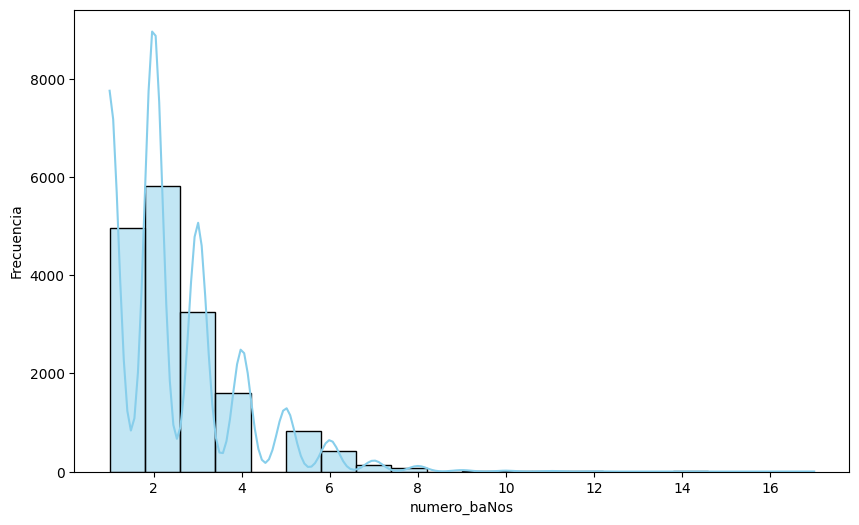

In [422]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  bins=20, kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

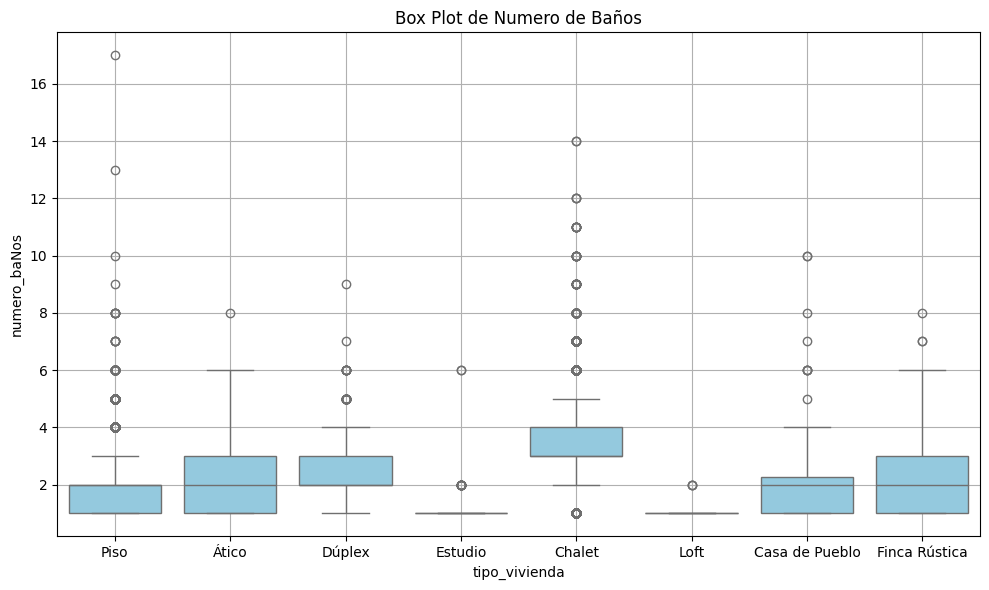

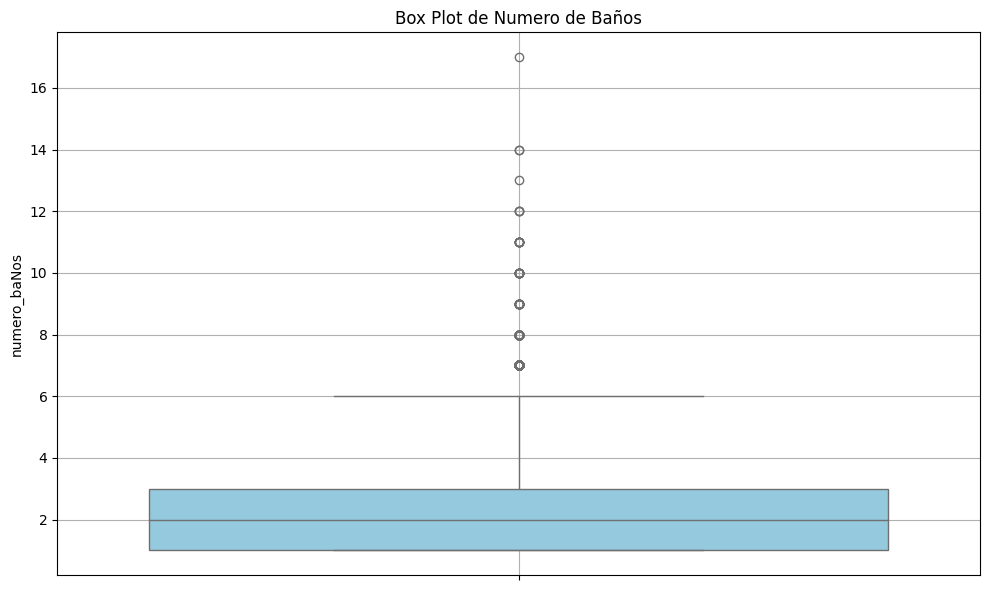

In [423]:
#Pintamos el diagrama de bigotes de3 la variable "metros_cuadrados_utiles" para cada tipo de vivienda para sacar más conclusiones
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Baños')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Baños')
plt.grid(True)
plt.tight_layout()
plt.show()


In [424]:
# sigue habiendo valores atípicos de "numero_baNos" por lo que vamos cribar, pero siendo más cautelosos ya que puede haber viviendas muy grandes con un gran numero de baños.
# Cribaremos las viviendas con más de 10 baños, que son muy pocas.
# Eliminamos también las viviendas con 0 baños ya que por normativa toda vivienda debe tener un baño.
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
datos_atipicos = pd.concat([data_sin_reps[data_sin_reps[var]>10]]).sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")

Por el momento se tienen un total de  17115  registros.

Tras eliminar los registros con valores atípicos, quedan  17100  registros.



-Además se detecta una casuística "extraña" y es que hay viviendas con muchos baños y sin ninguna habitación. No tiene mucho sentido ya que esto no es una vivienda y tampoco nos interesan las viviendas a "medio hacer", es decir que tienen que edificarse por completo. Por lo que eliminaremos estas casuíticas donde el número de baños sea mayor a 2 y sin embargo el número de habitaciones sea 0.



In [425]:
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
datos_atipicos = (data_sin_reps[(data_sin_reps["numero_baNos"]>2) & (data_sin_reps["numero_habitaciones"]==0)]).sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")

Por el momento se tienen un total de  17100  registros.

Tras eliminar los registros con valores atípicos, quedan  17098  registros.



Media: 2.41 

Desviación Estándar: 1.40291101038968 

Máximo: 10 

Mínimo: 1 



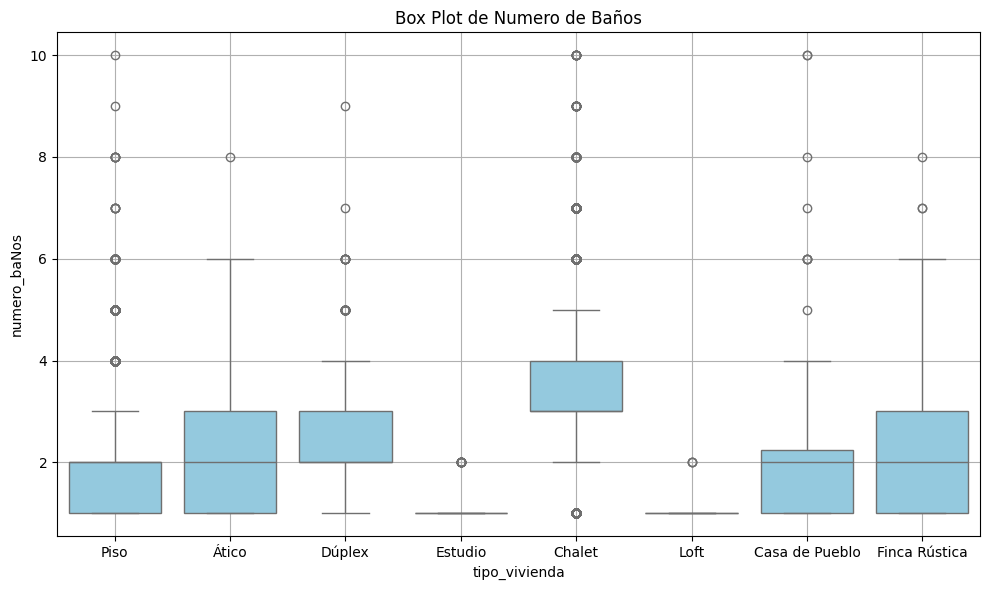

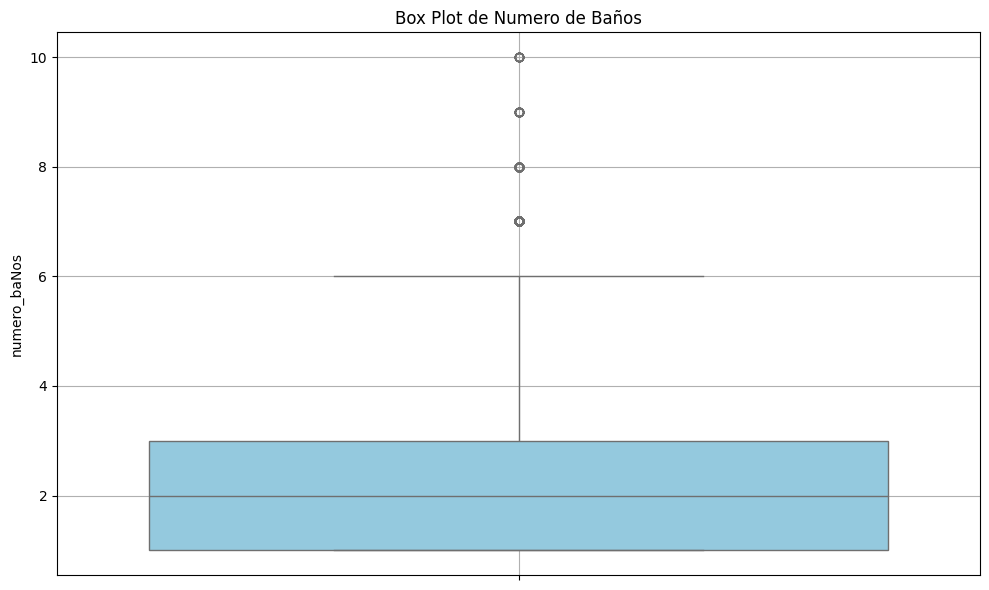

In [426]:
#Pintamos el diagrama de bigotes de la variable "numero_baNos"" para cada tipo de vivienda para sacar más conclusiones
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,2),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Baños')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Baños')
plt.grid(True)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'Frecuencia')

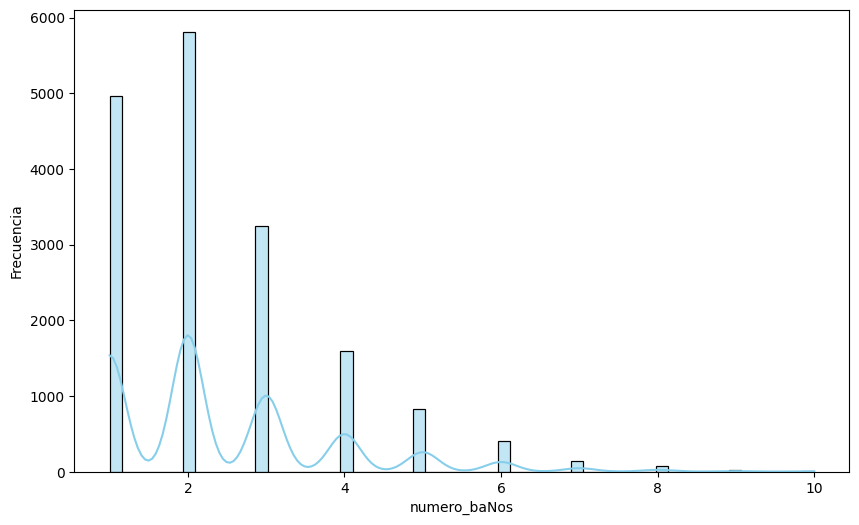

In [427]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

In [428]:
# Vamos a estudiar los valores atípicos de la variable "numero_habitaciones"

var = "numero_habitaciones"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

# El máximo es bastante atípico, ya que no es común que una vivienda habitual se tengan tantos habitaciones, aunque no se descarta.
# El número mínimo es 0, que podria ser un salon-habitacion tipo "estudio".

Media: 3.0 

Desviación Estándar: 1.5147142307826302 

Máximo: 20 

Mínimo: 0 



Text(0, 0.5, 'Frecuencia')

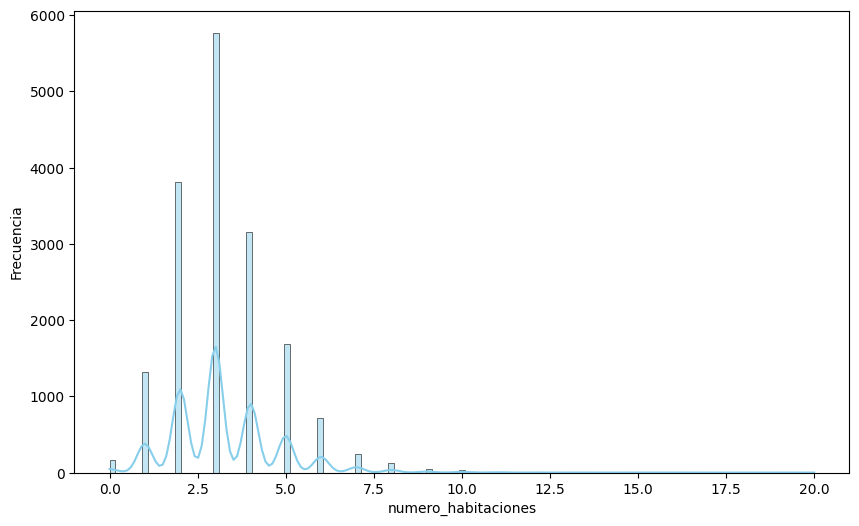

In [429]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

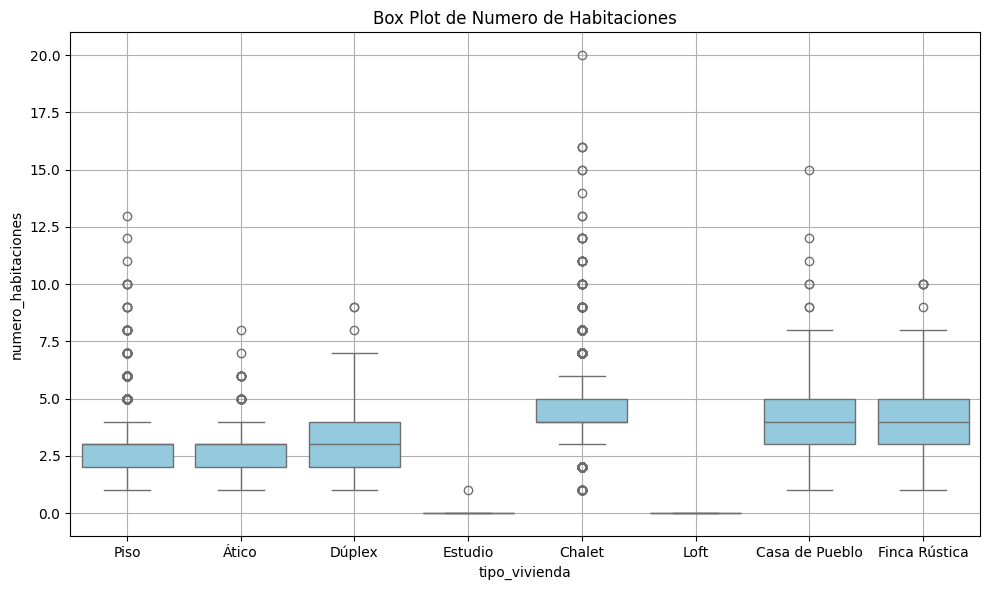

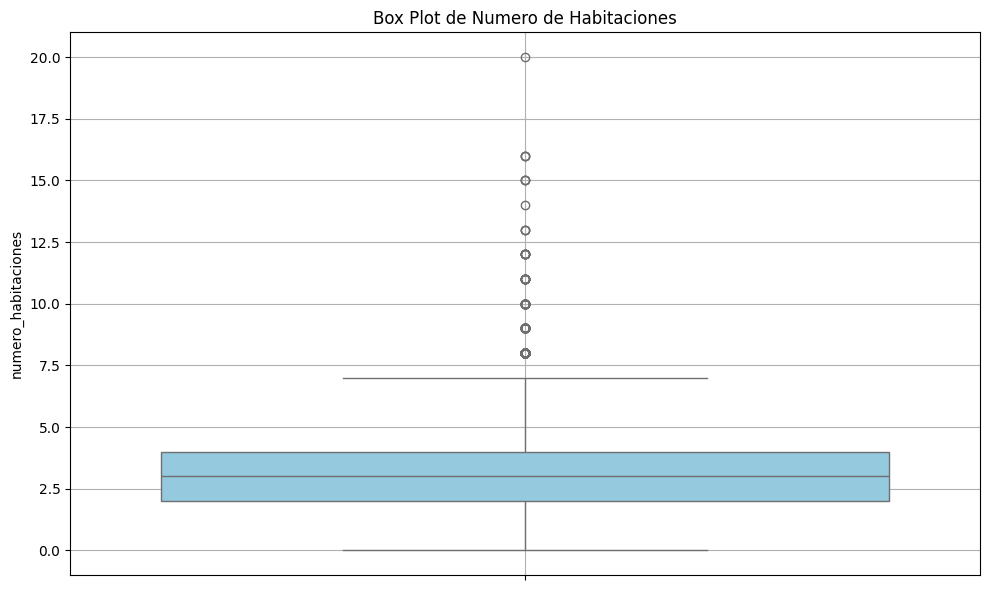

In [430]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Habitaciones')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Numero de Habitaciones')
plt.grid(True)
plt.tight_layout()
plt.show()


En este caso no cribaremos por el número de habitaciones, ya que 16 habitaciones tampoco es una locura y si que podría haber un Chalet con estas características.

In [431]:
# Vamos a estudiar los valores atípicos de la variable "antigUedad"

var = "antigUedad"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

# El máximo son 225 años de antigüedad, lo que parece una casa demasiado antigua. Seguramete, necesitará una gran reforma,
# El número mínimo es 0, que son las obras nuevas.

Media: 44.0 

Desviación Estándar: 31.223872187883018 

Máximo: 225 

Mínimo: 0 



Text(0, 0.5, 'Frecuencia')

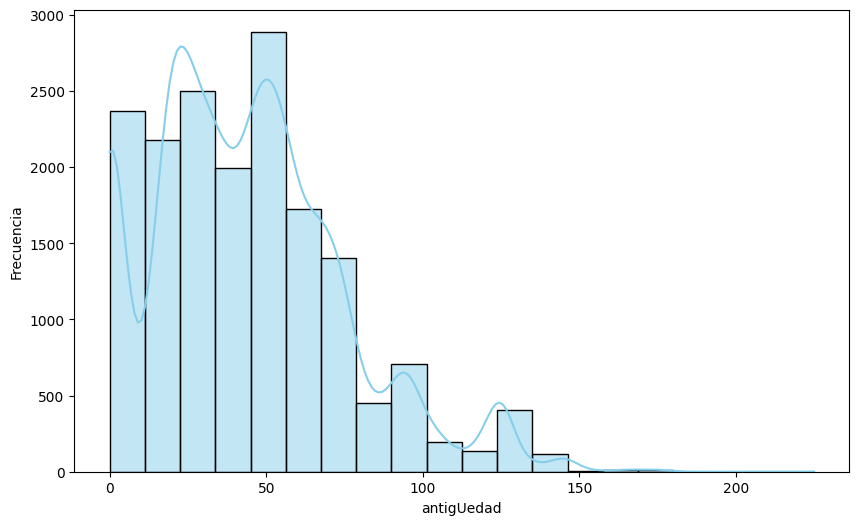

In [432]:
plt.figure(figsize=(10, 6))
sns.histplot(data_sin_reps[var],  bins=20, kde=True, color='skyblue', edgecolor='black')
plt.xlabel(var)
plt.ylabel('Frecuencia')

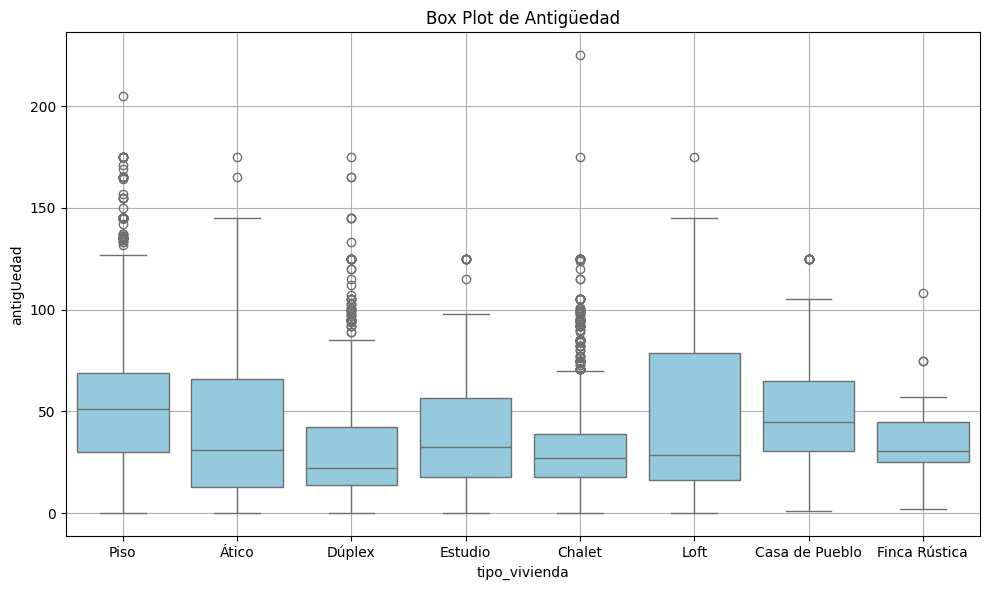

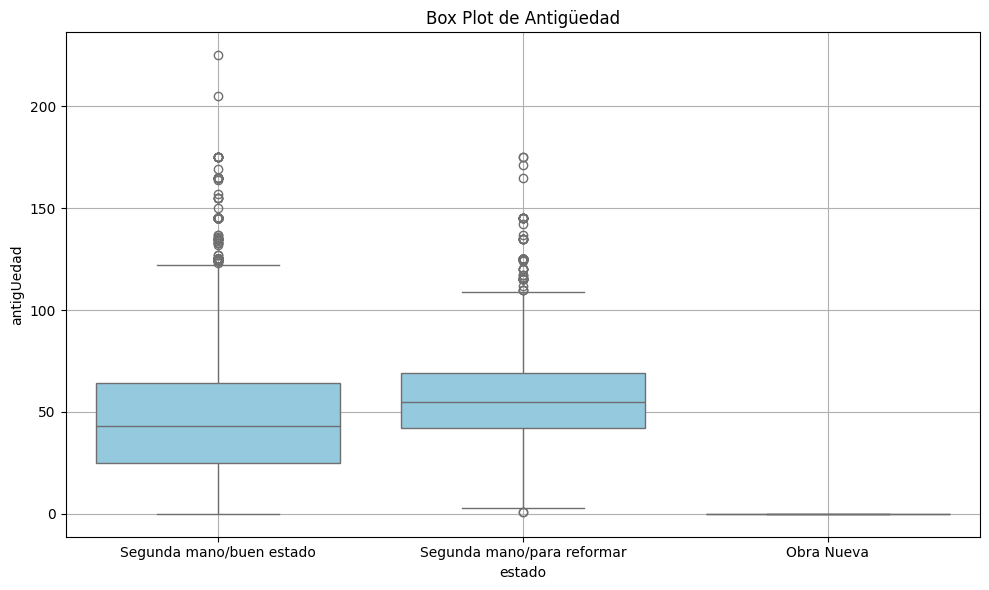

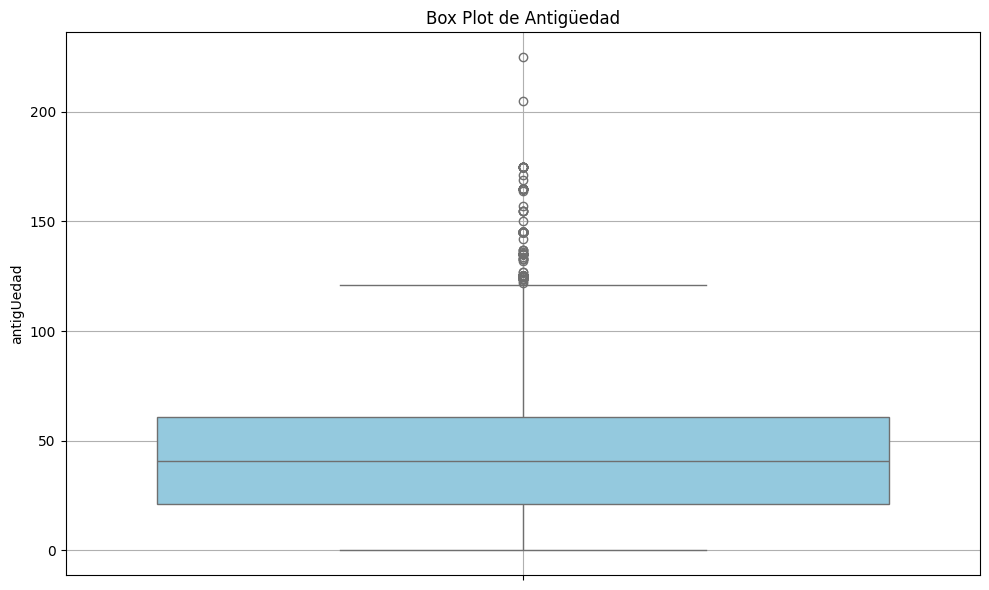

In [433]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Antigüedad')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x="estado", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Antigüedad')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Antigüedad')
plt.grid(True)
plt.tight_layout()
plt.show()


Realmente no son "outliers", si no viviendas menos frecuentes ya que seguramente necesitan una gran reforma.
La mayoría serán viviendas en pueblos que suelen ser casas más antiguas. Las viviendas de ciudades suelen ser más nuevas aunque no sucede así en Madrid centro.
Para ajustar un poco más la muestra y reducir la desviación estándar que es bastante grande, cribaremos por el límite superior mean+3*std


print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
datos_atipicos = data_sin_reps[data_sin_reps[var]>mean+3*std].sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")


std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

# El máximo son 225 años de antigüedad, lo que parece una casa demasiado antigua. Seguramete, necesitará una gran reforma,
# El número mínimo es 0, que son las obras nuevas.

plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Antigüedad')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de Antigüedad')
plt.grid(True)
plt.tight_layout()
plt.show()

POR ULTIMO, VAMOS CON EL PRECIO.

In [434]:
# Vamos a estudiar los valores atípicos de la variable "precio"

var = "precio"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")


# La desviación estándar del precio es muy grande porque se tienen datos de chalets con características muy diferentes.
# El máximo es 13.100.000€ (13 millones de euros). Podría ser real, pero seguro se aleja mucho del resto de la muestra y esto puede ser perjudicial para el modelo.
# En cambio, el mínimo es 24.900€, lo que es bastante raro conociendo el precio habitual de las viviendas.
# Vamos a revisar ambos casos, aunque la desviación estándar es muy grande y eso si que puede afectar mucho al modelo, hay que trabajar esta desviación.
# La media tambien es muy alta, ya que cada año las viviendas están más caras y se han incluido chalets que son bastante caros. Aun así la media afecta menos a un modelo ML.

Media: 900387.0 

Desviación Estándar: 1127776.9309632012 

Máximo: 23000000 

Mínimo: 24900 



In [435]:
# Veamos los datos para el registro donde el precio tiene el valor mínimo.

print(data_sin_reps[data_sin_reps[var]==data_sin_reps[var].min()],"\n")

# Es un chalet que está en un pueblo y que necesita reforma, pro lo que será más barata. 
# Es verdad que tiene solo 52 metros cuadrados (muy pequeña) y tiene 125 años de antigüedad...
# Aun así es demasiado sospechoso y se aleja de los precios habituales de la vivienda de hoy en día.

      precio  metros_cuadrados_totales  metros_cuadrados_utiles  numero_baNos  \
id                                                                              
1403   24900                        52                       52             1   

      numero_habitaciones  planta  antigUedad vivienda_unifamiliar  \
id                                                                   
1403                    2       2         125                   Si   

     tipo_vivienda                      estado  ... garaje terraza balcon  \
id                                              ...                         
1403        Chalet  Segunda mano/para reformar  ...     No      No     No   

     jardin armarios aire_acondicionado      calefaccion geohash_6  \
id                                                                   
1403     No       No                 No  Sin Calefaccion    ezjwmv   

     postal_code                municipio  
id                                         
1403       288

In [436]:
# Veamos los datos para el registro donde el precio tiene el valor máximo.

print(data_sin_reps[data_sin_reps[var]==data_sin_reps[var].max()],"\n")

# Es un chalet que encima está en Madrid ciudad, por lo que puede ser muy caro
# 1000 metros cuadrados con 7 baños y 7 habitaciones sin terraza, balcón, garaje, calefacción, aire acondicionado, piscina,  y ; por lo que se sospecha que falta informacion
# Eso sí, no tiene pisicina, ni jardín...


        precio  metros_cuadrados_totales  metros_cuadrados_utiles  \
id                                                                  
6940  23000000                      1000                     1000   

      numero_baNos  numero_habitaciones  planta  antigUedad  \
id                                                            
6940             7                    7       0          71   

     vivienda_unifamiliar tipo_vivienda                    estado  ... garaje  \
id                                                                 ...          
6940                   Si        Chalet  Segunda mano/buen estado  ...     No   

     terraza balcon jardin armarios aire_acondicionado      calefaccion  \
id                                                                        
6940      No     No     No       No                 No  Sin Calefaccion   

     geohash_6 postal_code municipio  
id                                    
6940    ezjqh1       28006    Madrid  

[1 rows x 24 c

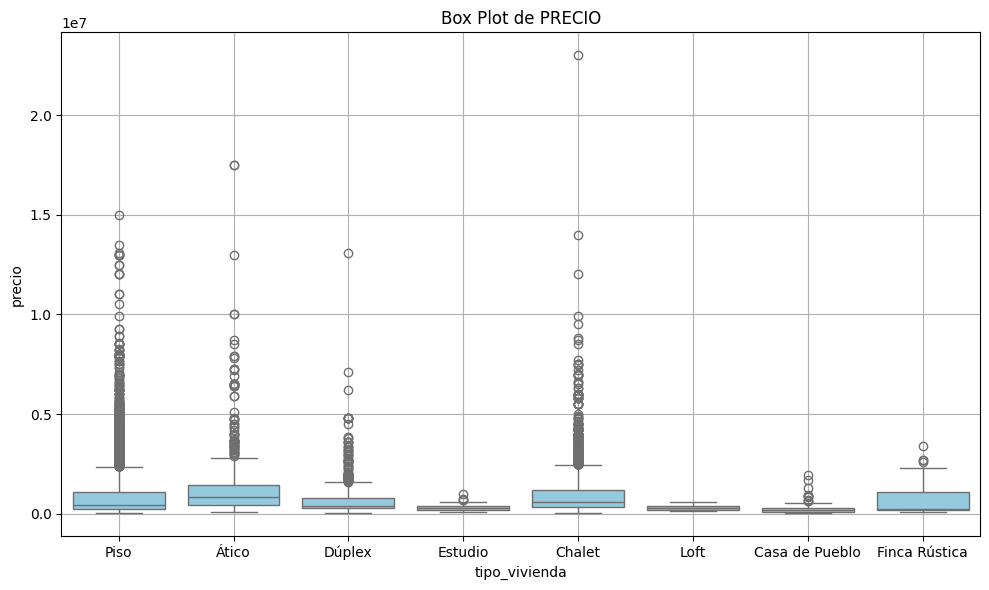

In [437]:
#Pintamos el diagrama de bigotes de3 la variable "precio" para cada tipo de vivienda para sacar más conclusiones
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y='precio', data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de PRECIO')
plt.grid(True)
plt.tight_layout()
plt.show()

#Este grafico es horrible, observamos que hay demasiada dispersión y afectará al modelo 100%. Hay que tomar decisiones y quitarnos estos modelos

TOMAMOS DECISIONES EN CUANTO AL PRECIO.
-Para el límite superior, vamos a reducirlo bastante, cribando aquellas viviendas lujosas que se escapan de lo habitual. Lim_pus = mean + 4*std
-Para el límite inferior, utilizaremos el dato medio del precio por m2 en Madrid que es de 4.700€. Aun asi, este dato está sesgado por la zona, 
por lo que tomaremos de referencia las zonas más baratas de Madrid que es de 854€ por m2 en Colmenar de la Oreja.
Y como el mínimo de m2 utiles son 40m2, entonces el precio mínimo de una vivienda en la comunidad de Madrid será de 34.080.

In [438]:
#vamos a quitar los datos atípicos del "precio"
print("Por el momento se tienen un total de ",data_sin_reps.shape[0]," registros.\n")
var="precio"
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
lim_inf, lim_sup = 34080, mean + 4*std
datos_atipicos = pd.concat([data_sin_reps[data_sin_reps[var]<lim_inf], data_sin_reps[data_sin_reps[var]>lim_sup]]).sort_index()
data_sin_reps=data_sin_reps.drop(datos_atipicos.index)
print("Tras eliminar los registros con valores atípicos, quedan ",data_sin_reps.shape[0]," registros.\n")

Por el momento se tienen un total de  17098  registros.

Tras eliminar los registros con valores atípicos, quedan  16923  registros.



Media: 830969.0 

Desviación Estándar: 853197.3167621312 

Máximo: 5400000 

Mínimo: 35000 



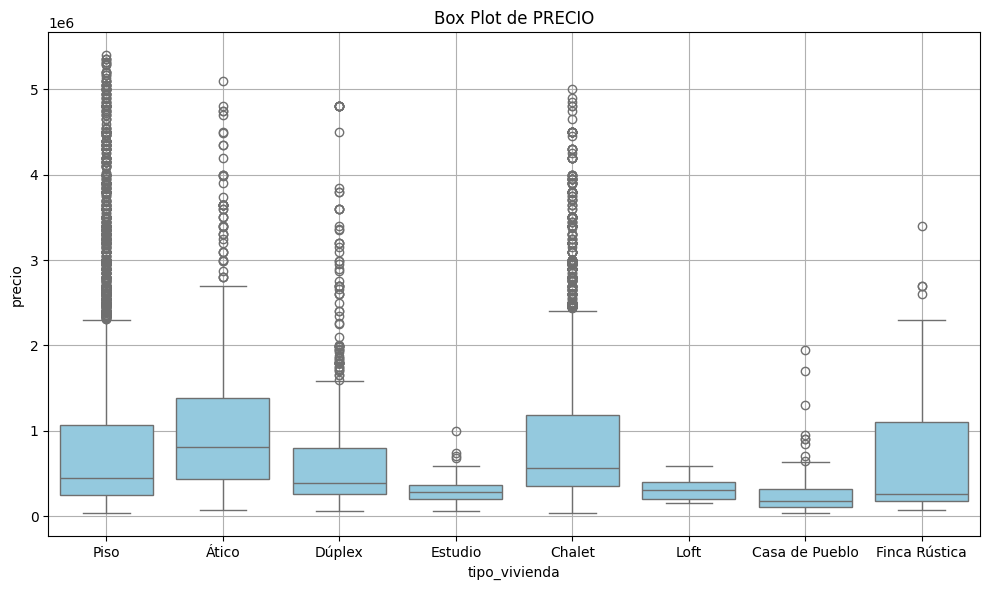

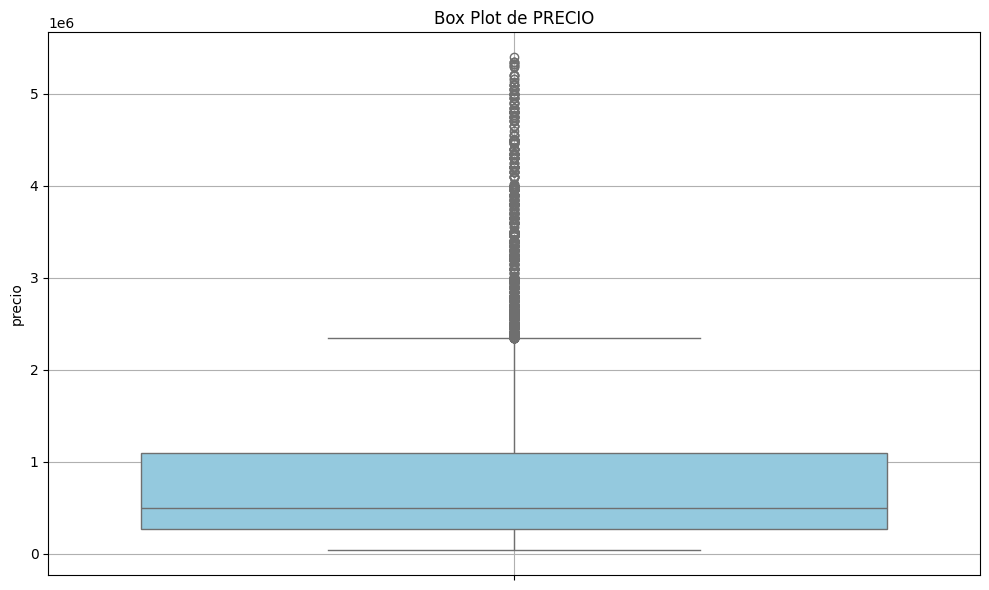

In [439]:
std = data_sin_reps[var].std()
mean = data_sin_reps[var].mean()
var_max = data_sin_reps[var].max()
var_min = data_sin_reps[var].min()

print("Media:",round(mean,0),"\n")
print("Desviación Estándar:",std,"\n")
print("Máximo:",var_max,"\n")
print("Mínimo:",var_min,"\n")

#Pintamos el diagrama de bigotes de3 la variable "precio" para cada tipo de vivienda para sacar más conclusiones
plt.figure(figsize=(10, 6))
sns.boxplot(x="tipo_vivienda", y='precio', data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de PRECIO')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(y=var, data=data_sin_reps, color='skyblue')
plt.title(f'Box Plot de PRECIO')
plt.grid(True)
plt.tight_layout()
plt.show()


El máximo ya es 5,4 millones de € y el mínimo 35.000 € lo que parecen bastante extremistas pero podrían ser casos reales. Ya dependerían del tamaño y el lujo.

No podemos hacer mucha más criba, pues aunque sean viviendas menos habituales, hay mucha variedad en el mercado inmobiliario y pueden ser precios reales.

Si que parecen muchos valores "atipicos" por el límite superior; pero ya vemos mucha más continuidad en los valores, lo que nos da sensación de realidad.

Teminamos el tratado de OUTLIERS con un total de 16.923 viviendas, una muestra bastante apta en cuanto al volumen por lo menos.

In [ ]:
#Exportar los datos tratados hasta el momento
#data_sin_reps.to_csv('CasasEnVenta_Madrid_NotOutliers.csv', sep=';', decimal='.')